<h1> DENGUE DATA ANALYSIS</h1>
<h3>Inclusive years: 2016 to 2020</h3>
<h4>Analyst: John Xyril B. Cabana</h4>

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

In [2]:
dengue = pd.read_csv('Datasets\\dengue.csv')

In [3]:
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [4]:
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [5]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [6]:
dengue['Year'] = dengue['Year'].astype('int')

In [7]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

<h1> DENGUE CASES TREND FROM 2016 - 2020 </h1>

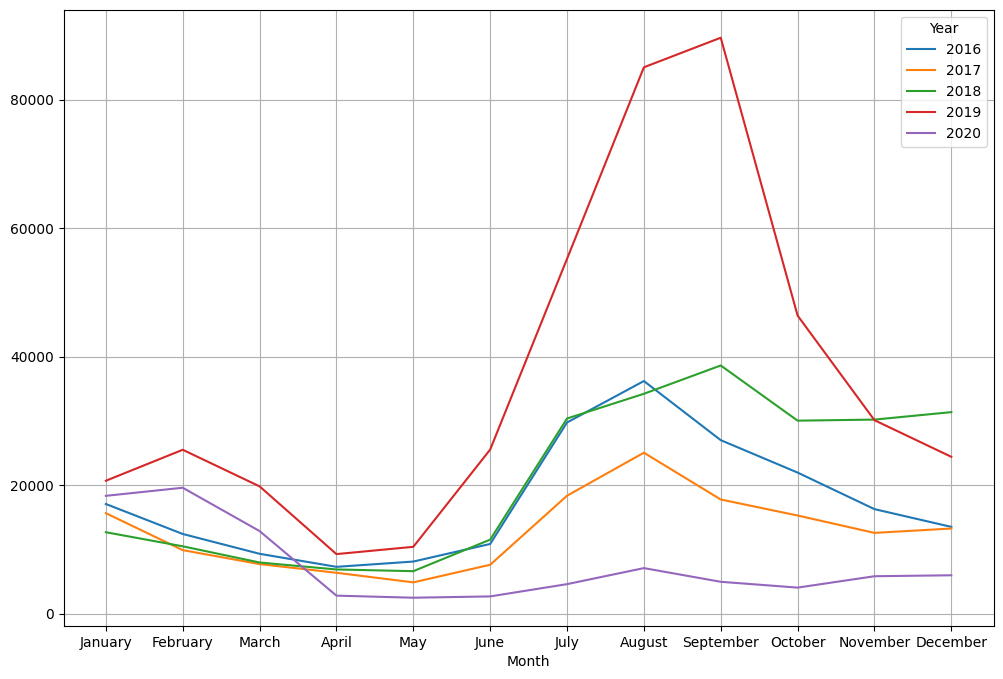

In [8]:

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)

monthly_cases = dengue.groupby(['Month', 'Year'])["Dengue_Cases"].sum()

monthly_cases.unstack().plot(kind='line')
plt.gcf().set_size_inches(12,8)
plt.grid(True)
plt.xticks(range(0,12), month_order)
plt.show()


<h1> LINE PLOT WITH SEABORN </h1>

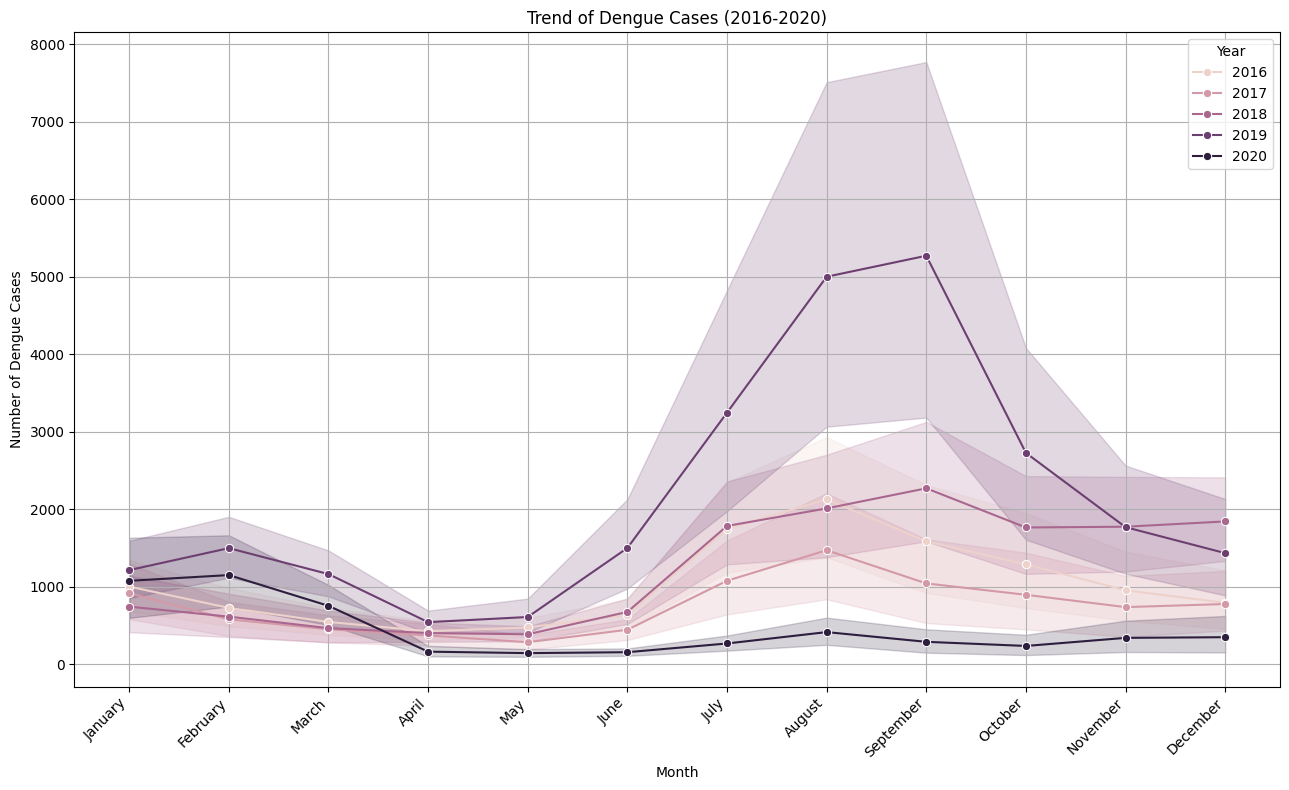

In [9]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)

# Create the line plot
sns.lineplot( data=dengue, x='Month', y='Dengue_Cases', hue='Year', marker='o')
plt.gcf().set_size_inches(13, 8)
plt.title('Trend of Dengue Cases (2016-2020)')
plt.xlabel('Month')
plt.ylabel('Number of Dengue Cases')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h3> Insight </h3>
<p>In 2016, the Dengvaxia vaccine was introduced as part of the country's dengue prevention efforts.5
Unfortunately, nearly two years after the campaign started, Sanofi, the vaccine developer, announced that Dengvaxia might cause ‘more severe disease’ in those who have not had previous dengue infection. By this time, over 800,000 children had been indiscriminately inoculated, and public outrage ensued, with lawsuits filed against Sanofi and various government officials due to claims of children's deaths from the vaccine and government corruption. The resulting mistrust against the public health sector plunged immunization rates, precipitating a measles outbreak in 2019. </p>

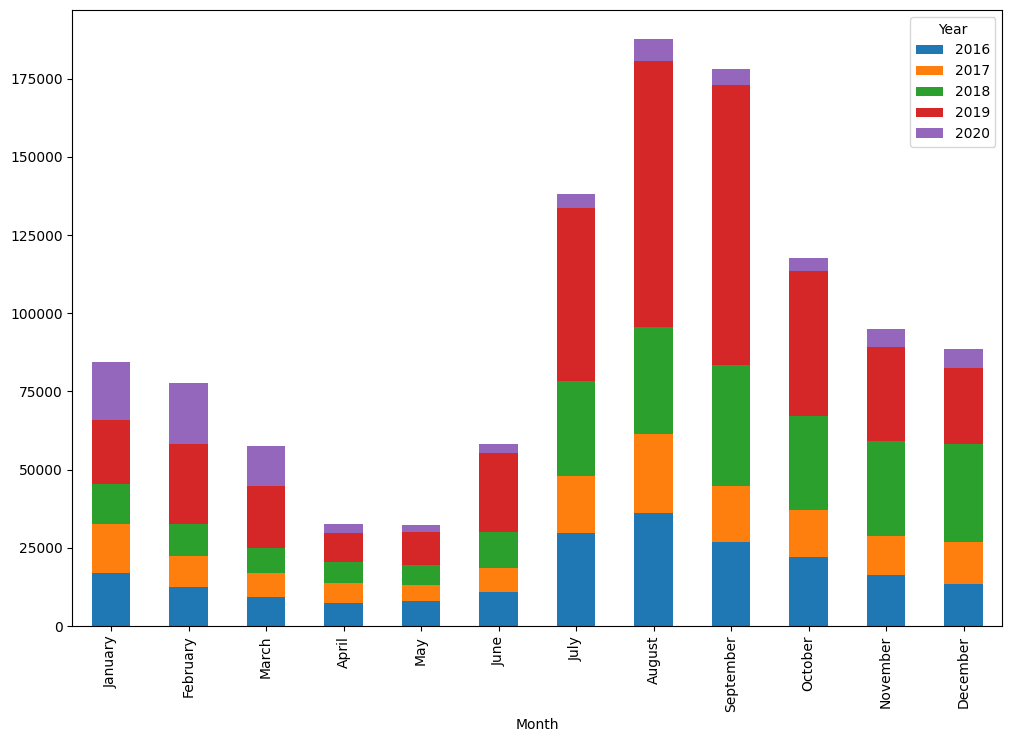

In [10]:
monthly_cases.unstack().plot(kind='bar', stacked=True)
plt.gcf().set_size_inches(12,8)
plt.show()

<h1> ANALYSIS OF DENGUE CASES PER REGION </h1>

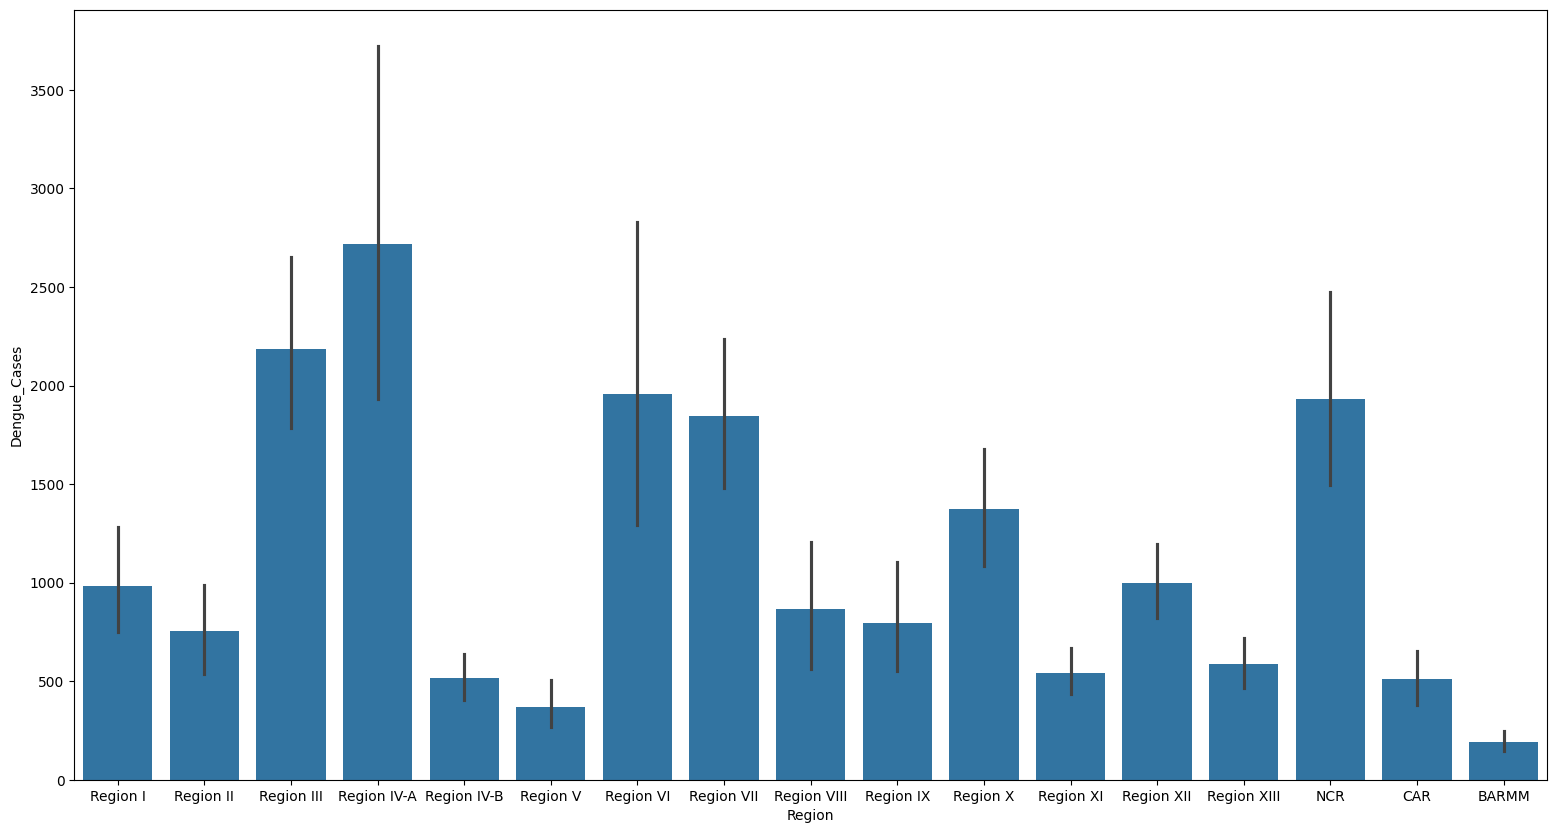

In [11]:
visual1 = sns.barplot(data=dengue, x='Region', y="Dengue_Cases")
plt.gcf().set_size_inches(19,10)
plt.show()

<h2> Insight </h2>
<p> The highest case was the most densely populated regions in the country specially the NCR, REGION III, and REGION IVA - CALABARZON region </p>

<h1> Mortality Rate per each Region </h1>

In [12]:
Regional_Death = dengue.groupby(["Region"])[['Dengue_Deaths', 'Dengue_Cases']].sum().reset_index()

In [13]:
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases
0,BARMM,332,11537
1,CAR,1008,30582
2,NCR,4008,115966
3,Region I,157,59066
4,Region II,193,45141
5,Region III,482,131064
6,Region IV-A,652,163029
7,Region IV-B,130,30849
8,Region IX,532,47781
9,Region V,185,22167


In [14]:
# Calculate mortality rate
Regional_Death["Mortality_Rate"] = np.round((Regional_Death["Dengue_Deaths"] / Regional_Death["Dengue_Cases"]) * 100,2)

In [15]:
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases,Mortality_Rate
0,BARMM,332,11537,2.88
1,CAR,1008,30582,3.30
2,NCR,4008,115966,3.46
3,Region I,157,59066,0.27
4,Region II,193,45141,0.43
5,Region III,482,131064,0.37
6,Region IV-A,652,163029,0.40
7,Region IV-B,130,30849,0.42
8,Region IX,532,47781,1.11
9,Region V,185,22167,0.83


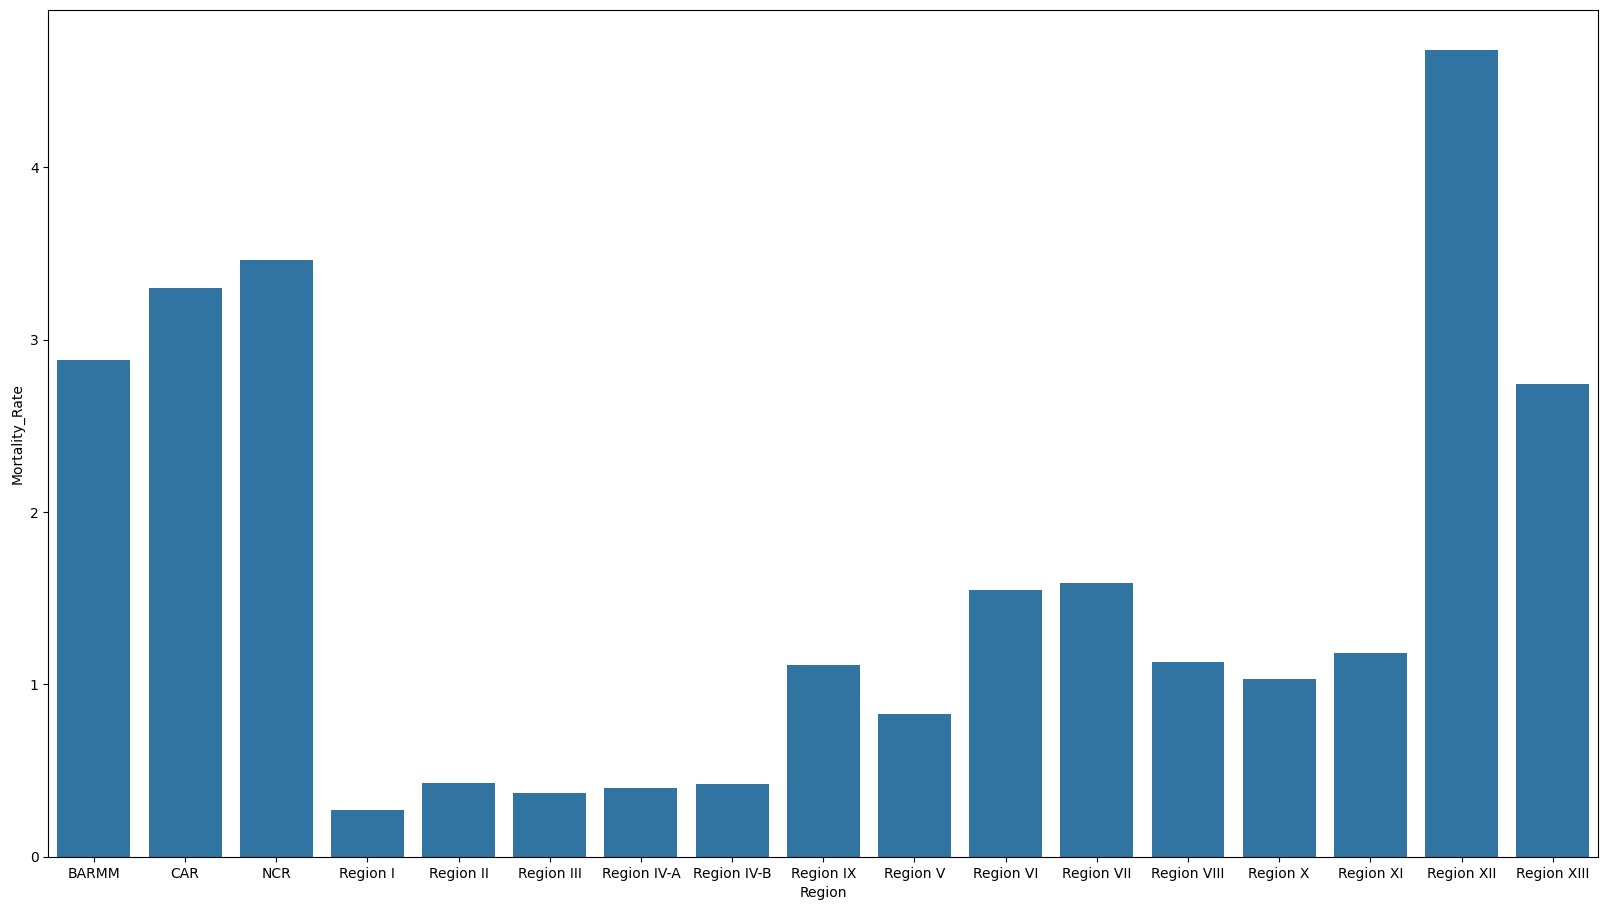

In [16]:
visual2 = sns.barplot(data=Regional_Death, x="Region",y="Mortality_Rate")
plt.gcf().set_size_inches(20,11)
plt.show()

<h3> Insight </h3>
<p> The DOH 7 reported that as of August 13, Region 7 has 11,403 confirmed dengue cases with 72 deaths. The DOH 7 said that 74 percent of the total number of confirmed dengue cases is in Cebu island. Cebu province has 4,457 cases with 27 mortalities.</p>

<h1> Mortality per Region thru Heat Map </h1>

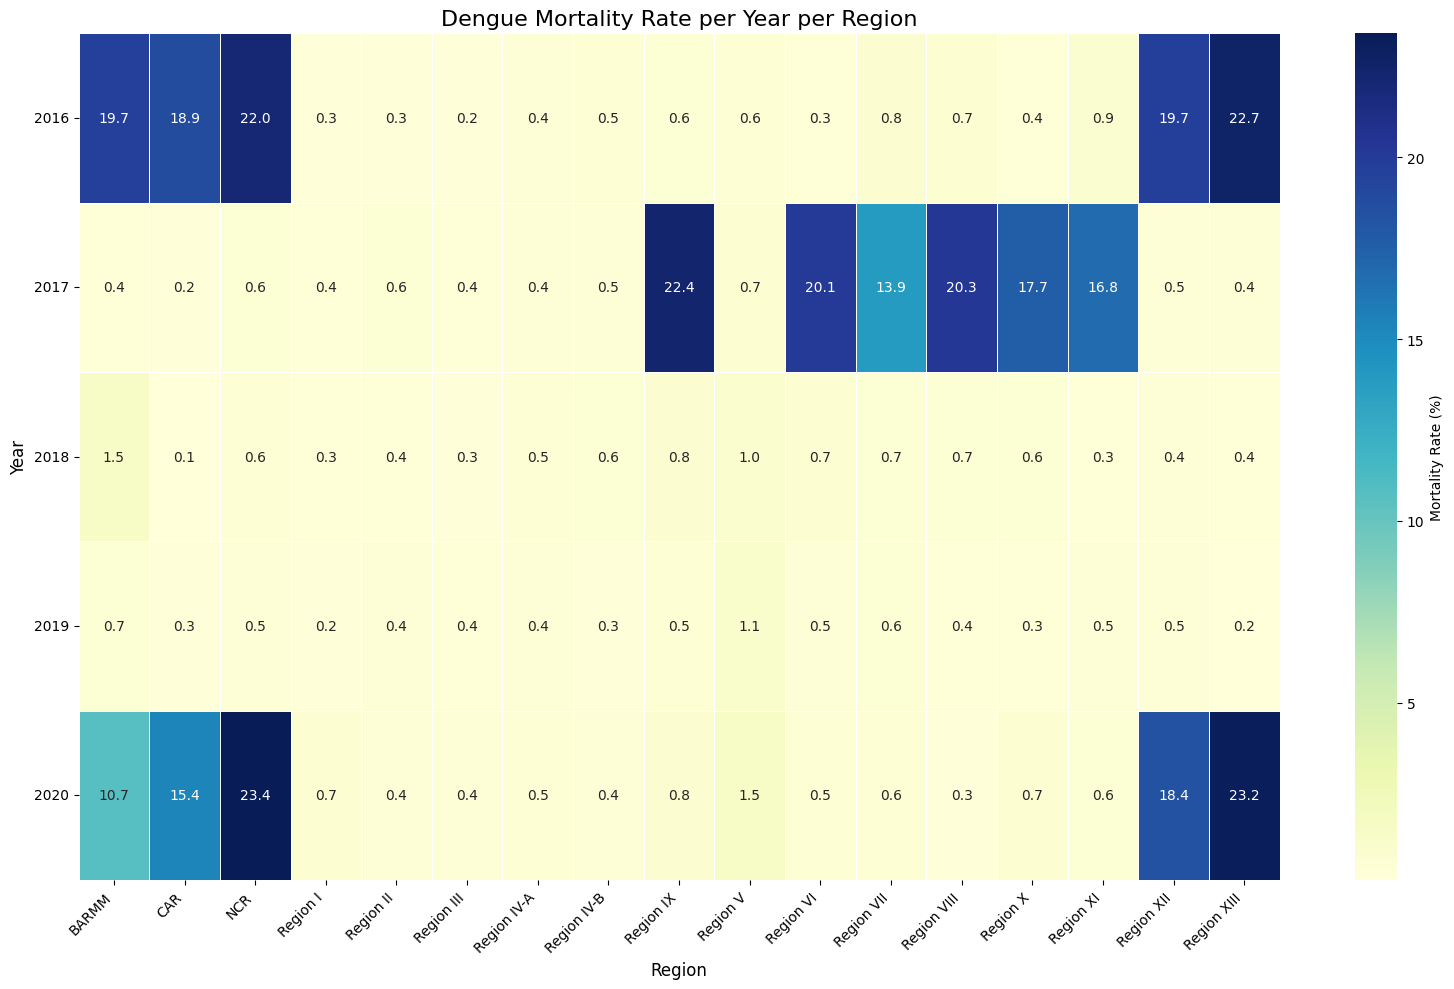

In [17]:

dengue['Mortality_Rate'] = (dengue['Dengue_Deaths'] / dengue['Dengue_Cases']) * 100

# Group by Year and Region and calculate the mean mortality rate
heatmap_data = dengue.groupby(['Year', 'Region'])['Mortality_Rate'].mean().unstack()

# Create the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Mortality Rate (%)'})
plt.title('Dengue Mortality Rate per Year per Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<h2> Insight </h2><br>
<p> The graph showed an alarming motality rate of dengue cases and deaths from 2016 to 2020, and upon closer examination the visualization clearly indicate a high mortality in NCR during 2016, and also in the BARMM Region with 11 percent death rate. On 2017, regions 6,7,8,9,10 and 11 indicate a high mmortality rate during that yar. </p>

<h1> PREDICTIVES </h1>

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Assuming your dataset is stored in a DataFrame called df
# Convert Year to numeric if it's currently stored as datetime
# df['Year'] = df['Year'].dt.year

# Check the data types of your features

# Convert Dengue_Cases to numeric if it's not already
# df['Dengue_Cases'] = pd.to_numeric(df['Dengue_Cases'])

dengue['Year'] = pd.to_numeric(dengue['Year'])
dengue['Dengue_Cases'] = pd.to_numeric(dengue['Dengue_Cases'])
# Split the data into features (X) and target variable (y)
X = dengue['Year'].values.reshape(-1, 1)
y = dengue['Dengue_Cases'].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dengue['Year'] = pd.to_datetime(dengue['Year'], format='%Y')
# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Make a prediction for a new year
new_year = 2025
new_cases = model.predict([[new_year]])
print("Predicted number of dengue cases in", new_year, ":", new_cases[0])


Mean Squared Error: 1805441.73572055
Predicted number of dengue cases in 2025 : 1280.286494492415


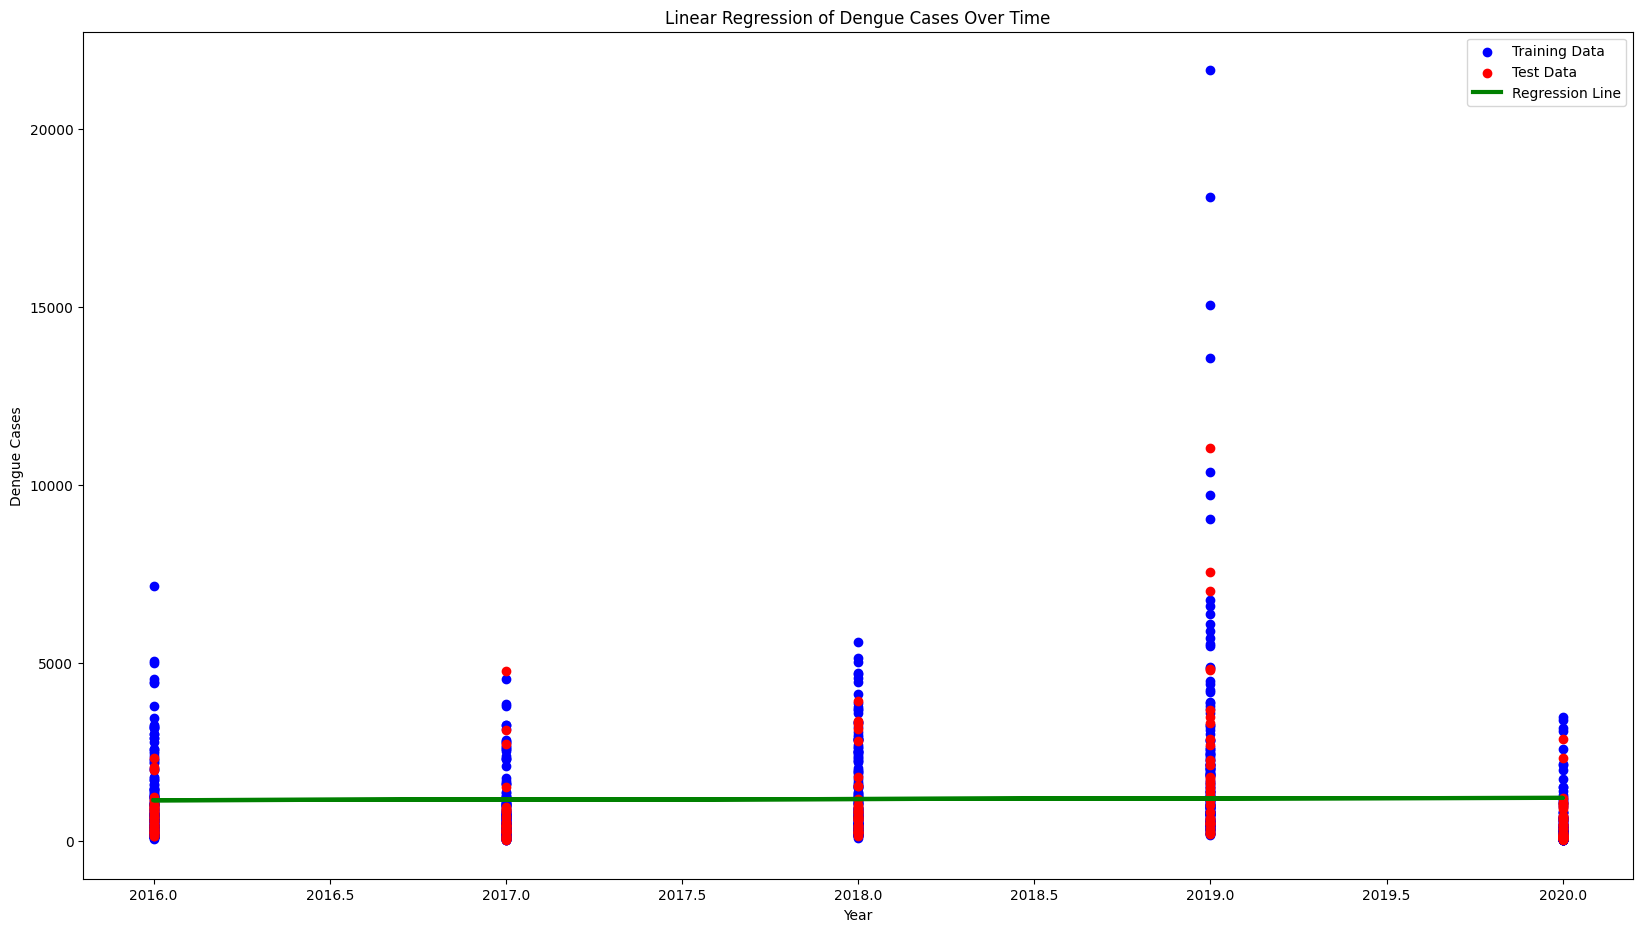

In [19]:

plt.scatter(X_train, y_train, color='blue', label='Training Data')


plt.scatter(X_test, y_test, color='red', label='Test Data')


plt.plot(X_test, y_pred, color='green', linewidth=3, label='Regression Line')


plt.xlabel('Year')
plt.ylabel('Dengue Cases')
plt.title('Linear Regression of Dengue Cases Over Time')
plt.legend()

# Show plot
plt.gcf().set_size_inches(20,11)
plt.show()


In [22]:
dengue['Year'] = pd.to_datetime(dengue['Year'], format='%Y')

In [21]:
dengue_NCR = dengue.groupby([{dengue[dengue["Region"]=="NCR"],["Dengue_Deaths"]}]).sum()

TypeError: unhashable type: 'DataFrame'

In [ ]:
dengue_NCR = dengue[dengue["Region"]=="NCR"].groupby("Region")["Dengue_Cases"].sum()

In [ ]:
dengue_NCR

In [ ]:
dengue["Region"]=="NCR"

In [ ]:
dengue

In [ ]:
dengue_NCR_2016 = dengue[(dengue["Region"]=="NCR") & (dengue["Year"]=="2016")]["Dengue_Cases"].sum()


In [ ]:
dengue_NCR_2016

In [ ]:
dengue["Year"] == "2016"

<h1 style="background-color:#47c6ce">INSIGHT NO.1</h1>
<h2>Region of with the highest dengue cases</h2>

In [ ]:
high_cases= dengue.groupby('Region')['Dengue_Cases'].sum().max()
region_cases = dengue.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)


plt.figure(figsize=(10,6))
sns.barplot(x=region_cases.values, y=region_cases.index, palette='Reds_r')

plt.title('Total Dengue Cases per Region')
plt.xlabel('Total Dengue Cases')
plt.ylabel('Region')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.2</h1>
<h2>2. Dengue Cases Per Region Highest and Lowest</h2>

In [ ]:
region_compare = dengue.groupby('Region')[['Dengue_Cases']].sum().reset_index()
region_compare = region_compare.sort_values(by='Dengue_Cases', ascending=False)
region_compare.head(5), region_compare.tail(5)

In [ ]:
top_5 = region_compare.head(5)
bottom_5 = region_compare.tail(5)

# Create figure
plt.figure(figsize=(12,6))

# Plot top 5 regions in red
sns.barplot(x=top_5['Dengue_Cases'], y=top_5['Region'], palette='Reds', label="Top 5 Regions")

# Plot bottom 5 regions in blue
sns.barplot(x=bottom_5['Dengue_Cases'], y=bottom_5['Region'], palette='Blues', label="Bottom 5 Regions")

# Titles & Labels
plt.title('Top 5 vs Bottom 5 Dengue Cases per Region')
plt.xlabel('Total Dengue Cases')
plt.ylabel('Region')


# Show the plot
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.3</h1>

<h2>3. Top 5 region with the most dengue deaths</h2>

In [ ]:
top5= dengue.groupby('Region')[['Dengue_Deaths']].sum().reset_index()
top5=top5.sort_values(by='Dengue_Deaths',ascending=False).head(5)

In [ ]:
top5

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top5['Dengue_Deaths'], y=top5['Region'], palette='Greens')

plt.title('Top 5 Regions with Highest Dengue Deaths')
plt.xlabel('Total Dengue Deaths')
plt.ylabel('Region')
plt.show()

<h2>3. Yearly Dengue Cases Increasing or Not?</h2>

In [ ]:
yearly=dengue.groupby('Year')[['Dengue_Cases']].sum().reset_index()
yearly

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly['Year'], y=yearly['Dengue_Cases'], marker='o', linestyle='-')

plt.title('Dengue Cases Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Dengue Cases')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.4</h1>
<h2>4. Top 5 Regions with lowest Dengue Deaths</h2>

In [ ]:
high=dengue.groupby('Region')[['Dengue_Deaths']].sum().reset_index()
high=high.sort_values(by='Dengue_Deaths',ascending=True).head(5)

(high)

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=high['Dengue_Deaths'], y=high['Region'], palette='RdBu')

plt.title('Bottom 5 Regions with Lowest Dengue Deaths')
plt.xlabel('Total Dengue Deaths')
plt.ylabel('Region')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.5</h1>
<h2>5. Fatality rate of the top 3 most affected regions over the years</h2>

In [ ]:
top3=dengue.groupby('Region')['Dengue_Cases'].sum().nlargest(3).index

top_fatal= dengue[dengue['Region'].isin(top3)]

top_fatal['Fatality Rate (%)']=(top_fatal['Dengue_Deaths'] / top_fatal['Dengue_Cases'])

top_fatal

In [ ]:
plt.figure(figsize=(12,6))

# Plot fatality rate for each top 3 region
for region in top3:
    dengue = top_fatal[top_fatal['Region'] == region]
    plt.plot(dengue['Year'], dengue['Fatality Rate (%)'], marker='o', linestyle='-', label=region)

plt.title('Fatality Rate Over the Years for Top 3 Regions')
plt.xlabel('Year')
plt.ylabel('Fatality Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.6</h1>
<h2>6. Top 5 regions with the most dengue cases</h2>

In [ ]:
top_c= dengue.groupby('Region')['Dengue_Cases'].sum().nlargest(5)
top_c

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(top_c, labels=top_c.index, autopct='%1.1f%%', colors=['red', 'orange', 'yellow', 'pink', 'brown'])
plt.title('Proportion of Dengue Cases in Top 5 Regions')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.7</h1>
<h2>7. What is overall fatality rate per region?</h2>

In [ ]:
fatal= dengue.groupby('Region').sum()[['Dengue_Cases','Dengue_Deaths']]
fatal['Fatality Rate (%)'] = (fatal['Dengue_Deaths'] / fatal['Dengue_Cases']) * 100
fatal

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=fatal['Dengue_Cases'], y=fatal['Fatality Rate (%)'], hue=fatal.index, s=100, palette='coolwarm')

plt.title('Fatality Rate vs. Dengue Cases by Region')
plt.xlabel('Total Dengue Cases')
plt.ylabel('Fatality Rate (%)')
plt.grid(True)
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.8</h1>
<h2>8. How many Dengue cases were reported Each Year?</h2>

In [ ]:
year = dengue.groupby('Year')['Dengue_Cases'].sum()
year

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(year.index, year.values, marker='o', linestyle='-', color='red')

plt.title('Yearly Dengue Cases Trend')
plt.xlabel('Year')
plt.ylabel('Total Dengue Cases')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis for readability
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.9</h1>
<h2>9. What are the worst dengue months?</h2>

In [ ]:
month= dengue.groupby('Month')['Dengue_Cases'].sum().sort_values(ascending=False)
month

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=month.index, y=month.values, palette='magma')

plt.title('Total Dengue Cases Per Month')
plt.xlabel('Month')
plt.ylabel('Total Dengue Cases')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.10</h1>
<h2>10. is there a correlation between dengue cases and deaths?</h2>

In [ ]:
corr = dengue['Dengue_Cases'].corr(dengue['Dengue_Deaths'])
corr

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=dengue['Dengue_Cases'], y=dengue['Dengue_Deaths'], alpha=0.6, color='red')

plt.title('Correlation Between Dengue Cases and Deaths')
plt.xlabel('Dengue Cases')
plt.ylabel('Dengue Deaths')
plt.grid(True)
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.11</h1>
<h2>11. Which regions have the most consistent dengue cases?</h2>

In [ ]:
reg= dengue.groupby('Region')['Dengue_Cases'].std().sort_values()
reg

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=reg.values ,y=reg.index , palette='viridis')
plt.title('regions have the most consistent dengue cases')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.12</h1>
<h2>12. Which region had the highest and lowest dengue cases?</h2>

In [ ]:
max_region = dengue.loc[dengue['Dengue_Cases'].idxmax()]
min_region = dengue.loc[dengue['Dengue_Cases'].idxmin()]

max_region[['Region','Dengue_Cases']] , min_region[['Region','Dengue_Cases']]

In [ ]:
regions = [max_region['Region'], min_region['Region']]
cases = [max_region['Dengue_Cases'], min_region['Dengue_Cases']]

plt.figure(figsize=(8,5))
sns.barplot(x=regions, y=cases, palette=['darkred', 'green'])

plt.title('Region with Highest & Lowest Dengue Cases')
plt.xlabel('Region')
plt.ylabel('Dengue Cases')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.13</h1>
<h2>13. Top 3 region with the highest fatality rate</h2>

In [ ]:
fatal_rate = dengue.groupby('Region').sum()[['Dengue_Cases','Dengue_Deaths']]
fatal_rate['Fatality Rate (%)'] = (fatal_rate['Dengue_Deaths'] / fatal_rate['Dengue_Cases']) * 100
top3= fatal_rate.nlargest(3,'Fatality Rate (%)')
top3

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=top3.index, y=top3['Fatality Rate (%)'], palette='Reds_r')

plt.title('Top 3 Regions with Highest Fatality Rate (%)')
plt.xlabel('Region')
plt.ylabel('Fatality Rate (%)')
plt.ylim(0, top3['Fatality Rate (%)'].max() + 1)  # Adjusts y-axis for better visibility
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.14</h1>
<h2>14. Which region had the biggest dengue outbreak in a single year?</h2>

In [ ]:
big = dengue.loc[dengue['Dengue_Cases'].idxmax(),['Year','Region','Dengue_Cases']]
big

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=[big['Region']], y=[big['Dengue_Cases']], color='red')

plt.title(f"Worst Dengue Outbreak in {big['Year']}")
plt.xlabel("Region")
plt.ylabel("Total Dengue Cases")
plt.ylim(0, big['Dengue_Cases'] + 1000)  # Adjust height for better visibility
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.15</h1>
<h2>15. Which region had the highest total dengue  cases over all years?</h2>

In [ ]:
reg_total = dengue.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)
reg_total

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(reg_total.head(10), labels=reg_total.head(10).index, autopct='%1.1f%%', colors=sns.color_palette('Reds', 10))

plt.title('Proportion of Dengue Cases in Top 10 Regions')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.16</h1>
<h2>16. which year had the highest number of cases for each region</h2>

In [ ]:
high_case= dengue.loc[dengue.groupby('Region')['Dengue_Cases'].idxmax(),['Region','Year','Dengue_Cases']]
high_case

In [ ]:
heatmap_data = high_case.pivot(index='Region', columns='Year', values='Dengue_Cases')

# Create the heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt=".0f", linewidths=0.5)

plt.title('Peak Dengue Cases per Region by Year')
plt.xlabel('Year')
plt.ylabel('Region')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.17</h1>
<h2>17. Which Regions Have the Most Unstable Dengue Cases Over the Years?</h2>

In [ ]:
region_volatile = dengue.groupby('Region')['Dengue_Cases'].std().sort_values(ascending= False)
region_volatile

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=region_volatile.values, y=region_volatile.index, palette='inferno')

plt.title('Variability of Dengue Cases Across Regions (Standard Deviation)')
plt.xlabel('Standard Deviation of Dengue Cases')
plt.ylabel('Region')
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.18</h1>
<h1>18. Are Fatality Rates Declining Over the Years?</h1>

In [ ]:
fatality_trend = dengue.groupby("Year")["Dengue_Deaths"].sum() / dengue.groupby("Year")["Dengue_Cases"].sum()
fatality_trend

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x=fatality_trend.index, y=fatality_trend.values, marker='o', color='red')

plt.title("Dengue Fatality Rate Trend Over the Years")
plt.xlabel("Year")
plt.ylabel("Fatality Rate (%)")
plt.ylim(0, fatality_trend.max() * 1.2)  # Adjust Y-axis for better visibility
plt.grid(True)
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.19</h1>
<h2>19. Which Year Had the Highest Overall Dengue Cases?</h2>

In [ ]:
highest_case_year = dengue.groupby("Year")["Dengue_Cases"].sum().idxmax()
highest_case_year

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_cases.index, y=yearly_cases.values, marker='o', color='red')

# Annotate the highest case year
plt.text(highest_case_year, yearly_cases.max(), f"Peak: {highest_case_year}", 
         ha="right", va="bottom", fontsize=12, color="black", fontweight="bold")

plt.title("Dengue Cases Trend Over the Years")
plt.xlabel("Year")
plt.ylabel("Dengue Cases")
plt.grid(True)
plt.show()

<h1 style="background-color:#47c6ce">INSIGHT NO.20</h1>
<h2>20. Which Regions Have the Most Fatalities Compared to Total Deaths?</h2>

In [ ]:
region_fatality_share = (dengue.groupby("Region")["Dengue_Deaths"].sum() / dengue["Dengue_Deaths"].sum()) * 100
region_fatality_share.sort_values(ascending=False)

In [ ]:
plt.figure(figsize=(10,6))
region_fatality_share.sort_values(ascending=True).plot(kind='pie', x="Region", autopct='%1.1f%%', cmap='Reds')

plt.title("Share of Dengue Fatalities by Region")
plt.ylabel("")  # Remove ylabel for clarity
plt.show()